# 02. Baseline Benchmark: PID vs. Pure RL

**Objective:** Establish performance baselines for the 1-DOF joint with Stribeck friction.
**Goal:** Prove that PID fails at stiction (zero-crossing) and Pure RL is sample inefficient.

---

### 1. Setup Environment
Import the simulator wrapper and the controllers.

In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Add root to path to import sim
sys.path.append(os.path.abspath('..'))

# UPDATED IMPORT: Use the wrapper for numpy compatibility
from sim.baseline_env import SimpleJointSim 
from sim.controllers import PIDController, PPOAgent

### 2. PID Benchmark (The Engineer's Baseline)
We use a standard PID. 
**Look for:** The "Stick-Slip" phenomenon where the red line flattens at zero velocity while the target continues.

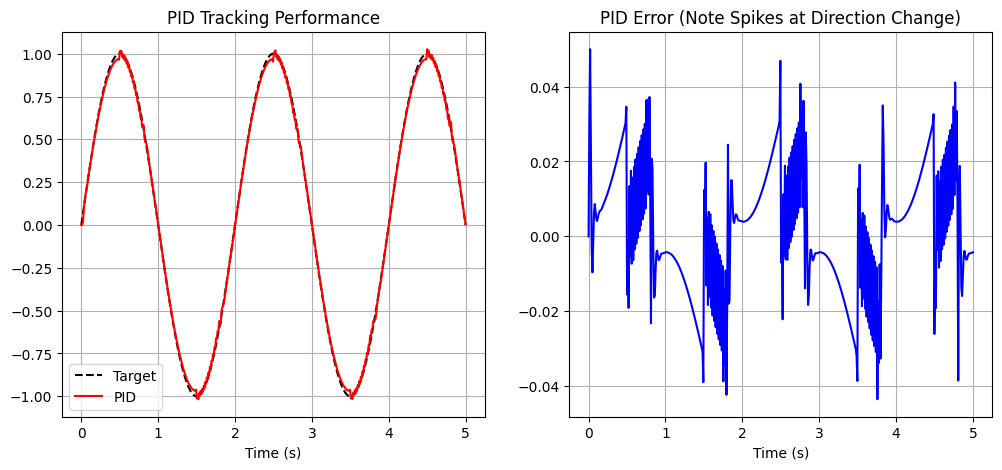

In [7]:
# --- CONFIGURATION ---
DT = 0.01
KP, KI, KD = 15.0, 0.5, 0.1  # Tuned for Stribeck

# --- INITIALIZE ---
sim = SimpleJointSim(dt=DT, friction_model='stribeck')
pid = PIDController(kp=KP, ki=KI, kd=KD, output_limits=(-10, 10), dt=DT)

# --- RUN SIMULATION ---
time_steps = 500
t_span = np.linspace(0, time_steps*DT, time_steps)
target_pos = np.sin(2 * np.pi * 0.5 * t_span) # 0.5 Hz Sine Wave

actual_pos = []
errors = []

state = sim.reset()
pid.reset()

for i in range(time_steps):
    target = target_pos[i]
    current_q = state[0]
    
    u = pid.compute(target, current_q)
    state, _, _, _ = sim.step(u)
    
    actual_pos.append(state[0])
    errors.append(target - state[0])

# --- PLOT RESULTS ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(t_span, target_pos, 'k--', label='Target')
plt.plot(t_span, actual_pos, 'r', label='PID')
plt.title('PID Tracking Performance')
plt.xlabel('Time (s)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_span, errors, 'b')
plt.title('PID Error (Note Spikes at Direction Change)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.savefig('../docs/figures/week5_pid_stiction_failure.png', dpi=300, bbox_inches='tight')
plt.show()

### 3. Pure RL Benchmark (The Black Box)
We train a PPO agent from scratch. 
**Look for:** How many episodes it takes to stop crashing. It should be slow.

Training PPO for 400 episodes...
Episode 0: Reward -20515722.00
Episode 50: Reward -2788866.00
Episode 100: Reward -2024.49
Episode 150: Reward -424.29
Episode 200: Reward -914.28
Episode 250: Reward -566.79
Episode 300: Reward -445.04
Episode 350: Reward -421.34


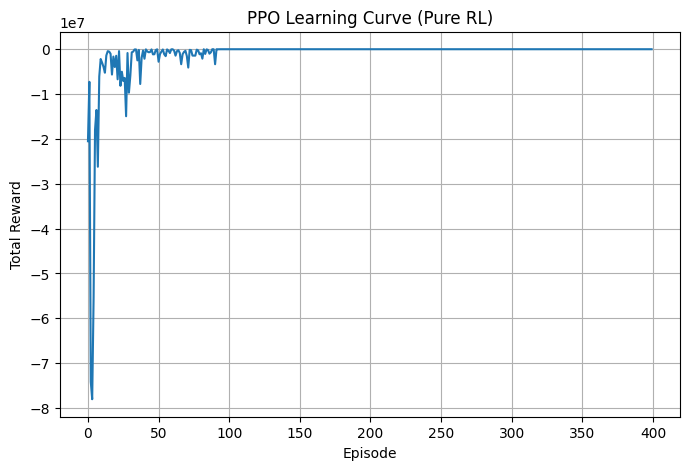

In [8]:
# --- CONFIGURATION ---
MAX_EPISODES = 400
MAX_STEPS = 300
UPDATE_EVERY = 600

# --- INITIALIZE ---
ppo = PPOAgent(state_dim=2, action_dim=1)
sim = SimpleJointSim(dt=DT, friction_model='stribeck')

timestep = 0
rewards_history = []

print(f"Training PPO for {MAX_EPISODES} episodes...")

for ep in range(MAX_EPISODES):
    state = sim.reset()
    state = np.array([0.0, 0.0]) 
    ep_reward = 0
    target = np.random.uniform(-1.0, 1.0)
    
    for t in range(MAX_STEPS):
        timestep += 1
        
        # RL Observation: [Error, Velocity]
        error = target - state[0]
        rl_state = np.array([error, state[1]])
        
        # Get Action
        action = ppo.select_action(rl_state)
        u = action[0] * 10.0 # Scale to torque limits
        
        # Step Env
        state, _, _, _ = sim.step(u)
        
        # Calculate Reward
        current_error = target - state[0]
        reward = - (current_error**2) - 0.01 * (u**2)
        
        # Store & Update
        ppo.memory.rewards.append(reward)
        ppo.memory.is_terminals.append(t == MAX_STEPS - 1)
        ep_reward += reward
        
        if timestep % UPDATE_EVERY == 0:
            ppo.update()
            
    rewards_history.append(ep_reward)
    
    if ep % 50 == 0:
        print(f"Episode {ep}: Reward {ep_reward:.2f}")

# --- PLOT CONVERGENCE ---
plt.figure(figsize=(8, 5))
plt.plot(rewards_history)
plt.title('PPO Learning Curve (Pure RL)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.savefig('../docs/figures/week5_ppo_convergence_slow.png', dpi=300, bbox_inches='tight')
plt.show()